In [4]:
import os
import sys

import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))




Make a plot that helps us decide what the image cutout size should be.

Loads in the SGA catalog

In [124]:
sga_file = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_sga_matched_dwarfs.fits"
sga_data = Table.read(sga_file)


In [125]:
def get_image_size(zred,return_arcmin=True):
    """
    Mimics the boundary:
    - For zred > 0.0125, return 1.53 arcmin
    - For zred <= 0.0125, return the value on the line connecting (0, 8) to (0.0125, 1.53)
    """
    zred = np.asarray(zred)  # Handles scalar or array input

    # Define slope and intercept for the line from (0,8) to (0.0125,1.53)
    x0, y0 = 0.0, 8.0
    x1, y1 = 0.0125, 1.53
    slope = (y1 - y0) / (x1 - x0)
    intercept = y0  # Since x0 = 0

    # Calculate the boundary value
    boundary_val = slope * zred + intercept

    # Apply the cutoff at zred = 0.0125
    img_size_arcmin = np.where(zred > 0.0125, 1.53, boundary_val)
    if return_arcmin:
        return img_size_arcmin
    else:
        img_size_pix = img_size_arcmin*60/0.262
        return img_size_pix.astype(int)

In [126]:
zred_grid = np.linspace(0,0.03,100)

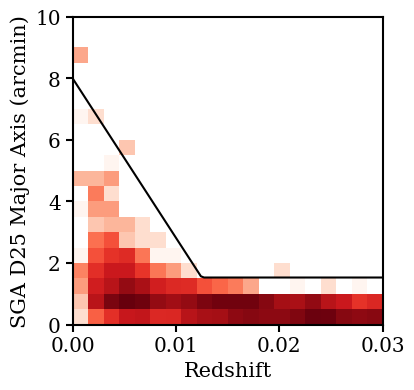

In [127]:
image_size = 2*sga_data["SGA_SMA_SB25"].data / 0.262

sga_data["IMAGE_SIZE_PIX"]= image_size

plt.figure(figsize = (4,4))
plt.hist2d( sga_data["Z"].data, 2*sga_data["SGA_SMA_SB25"].data/60, range=( (0,0.03), (0,10) ),bins=20,norm=LogNorm(),cmap = "Reds" )
# plt.hlines(y = 1.53,color = "k",xmin=0,xmax=0.03,lw = 2)
# plt.plot([0,0.0125],[8,1.53],color = "k",ls = "--",lw = 2)
plt.ylim([0,10])
plt.xlim([0,0.03])
plt.xticks([0,0.01,0.02,0.03])

plt.plot(zred_grid, get_image_size(zred_grid),color = "k")
plt.ylabel(r"SGA D25 Major Axis (arcmin)",fontsize = 15)
plt.xlabel("Redshift",fontsize =15)
# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/sga_d25_plots.png",bbox_inches="tight")
plt.show()